### ⚠️ Patched for Local Execution
This notebook was originally designed for Google Colab. It has been automatically patched:
- Google Colab-specific imports and `drive.mount()` calls have been commented out
- Colab file paths (`/content/drive/...`) have been replaced with relative paths (`./`)
- `!pip install` commands have been commented out (install packages in your venv instead)

**To run locally:** activate your Python virtual environment first, then run this notebook in VS Code or Jupyter.

In [2]:
pip install datasets transformers

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from datasets import load_dataset

ds = load_dataset('AI-Lab-Makerere/beans')
ds

c:\Users\aziz1\OneDrive\Desktop\hsoub academy\ok\02_Google_Colab_Notebooks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 1034
    })
    validation: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 133
    })
    test: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 128
    })
})

In [4]:
ex = ds['train'][450]
ex

{'image_file_path': '/home/albert/.cache/huggingface/datasets/downloads/extracted/967f0d9f61a7a8de58892c6fab6f02317c06faf3e19fba6a07b0885a9a7142c7/train/bean_rust/bean_rust_train.193.jpg',
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x500>,
 'labels': 1}

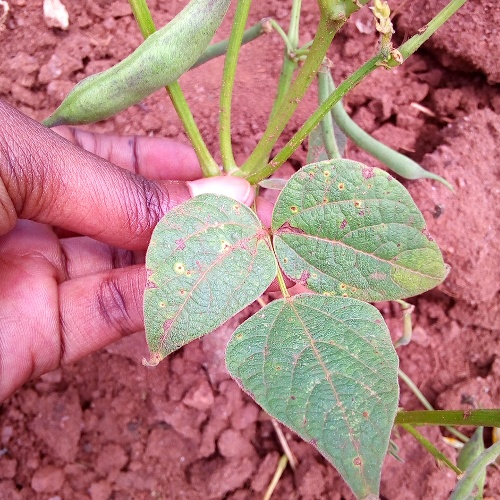

In [5]:
image = ex['image']
image

In [6]:
labels = ds['train'].features['labels']
labels

ClassLabel(names=['angular_leaf_spot', 'bean_rust', 'healthy'])

In [7]:
labels.int2str(ex['labels'])

'bean_rust'

In [8]:
from transformers import ViTForImageClassification, ViTImageProcessor


model_name_or_path = 'google/vit-base-patch16-224-in21k'
processor = ViTImageProcessor.from_pretrained(model_name_or_path)

In [9]:
processor

ViTImageProcessor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

In [10]:
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 7348.69it/s]


In [11]:
inputs = processor(images=image, return_tensors="pt")
pixel_values = inputs.pixel_values
pixel_values

tensor([[[[ 0.8902,  0.7333,  0.6706,  ...,  0.2392,  0.1843,  0.4118],
          [ 0.8980,  0.9529,  0.9529,  ...,  0.2784,  0.2706,  0.4745],
          [ 0.3569,  0.6549,  0.9686,  ...,  0.4039,  0.3961,  0.5294],
          ...,
          [ 0.3569,  0.2235,  0.2000,  ...,  0.4824,  0.3882,  0.2000],
          [ 0.2784,  0.1765,  0.2000,  ...,  0.4588,  0.5216,  0.5608],
          [ 0.2314,  0.2235,  0.2078,  ...,  0.5765,  0.5059,  0.5922]],

         [[ 0.6706,  0.3804,  0.1843,  ..., -0.3961, -0.4667, -0.2471],
          [ 0.6078,  0.6706,  0.7020,  ..., -0.3569, -0.3725, -0.1686],
          [-0.2314,  0.1922,  0.7490,  ..., -0.2549, -0.2471, -0.1137],
          ...,
          [-0.2235, -0.3490, -0.3647,  ..., -0.0902, -0.2157, -0.4039],
          [-0.2863, -0.3882, -0.3725,  ..., -0.1451, -0.0824, -0.0118],
          [-0.3333, -0.3490, -0.3725,  ..., -0.0353, -0.0980,  0.0431]],

         [[ 0.7176,  0.4588,  0.2863,  ..., -0.2784, -0.3569, -0.1451],
          [ 0.6471,  0.7098,  

In [12]:
import torch

with torch.no_grad():
  outputs = model(pixel_values)
  logits = outputs.logits

prediction = logits.argmax(-1)
print("Predicted class:", model.config.id2label[prediction.item()])

Predicted class: cucumber, cuke


In [13]:
def process_example(example):
    inputs = processor(example['image'], return_tensors='pt')
    inputs['labels'] = example['labels']
    return inputs

In [14]:
process_example(ds['train'][0])

{'pixel_values': tensor([[[[-0.5686, -0.5686, -0.5608,  ..., -0.0275,  0.1843, -0.2471],
          [-0.6078, -0.6000, -0.5765,  ..., -0.0353, -0.0196, -0.2627],
          [-0.6314, -0.6314, -0.6078,  ..., -0.2314, -0.3647, -0.2235],
          ...,
          [-0.5373, -0.5529, -0.5843,  ..., -0.0824, -0.0431, -0.0902],
          [-0.5608, -0.5765, -0.5843,  ...,  0.3098,  0.1843,  0.1294],
          [-0.5843, -0.5922, -0.6078,  ...,  0.2627,  0.1608,  0.2000]],

         [[-0.7098, -0.7098, -0.7490,  ..., -0.3725, -0.1608, -0.6000],
          [-0.7333, -0.7333, -0.7569,  ..., -0.3647, -0.3255, -0.5686],
          [-0.7490, -0.7490, -0.7725,  ..., -0.5373, -0.6549, -0.5373],
          ...,
          [-0.7725, -0.7804, -0.8196,  ..., -0.2235, -0.0353,  0.0824],
          [-0.7961, -0.8118, -0.8118,  ...,  0.1922,  0.3098,  0.3725],
          [-0.8196, -0.8196, -0.8275,  ...,  0.0824,  0.2784,  0.3961]],

         [[-0.9922, -0.9922, -1.0000,  ..., -0.5451, -0.3569, -0.7255],
          [-0

In [15]:
def transform(example_batch):
    inputs = processor([x for x in example_batch['image']], return_tensors='pt')

    inputs['labels'] = example_batch['labels']
    return inputs

In [16]:
prepared_ds = ds.with_transform(transform)

In [17]:
prepared_ds['train'][0:2]

{'pixel_values': tensor([[[[-0.5686, -0.5686, -0.5608,  ..., -0.0275,  0.1843, -0.2471],
          [-0.6078, -0.6000, -0.5765,  ..., -0.0353, -0.0196, -0.2627],
          [-0.6314, -0.6314, -0.6078,  ..., -0.2314, -0.3647, -0.2235],
          ...,
          [-0.5373, -0.5529, -0.5843,  ..., -0.0824, -0.0431, -0.0902],
          [-0.5608, -0.5765, -0.5843,  ...,  0.3098,  0.1843,  0.1294],
          [-0.5843, -0.5922, -0.6078,  ...,  0.2627,  0.1608,  0.2000]],

         [[-0.7098, -0.7098, -0.7490,  ..., -0.3725, -0.1608, -0.6000],
          [-0.7333, -0.7333, -0.7569,  ..., -0.3647, -0.3255, -0.5686],
          [-0.7490, -0.7490, -0.7725,  ..., -0.5373, -0.6549, -0.5373],
          ...,
          [-0.7725, -0.7804, -0.8196,  ..., -0.2235, -0.0353,  0.0824],
          [-0.7961, -0.8118, -0.8118,  ...,  0.1922,  0.3098,  0.3725],
          [-0.8196, -0.8196, -0.8275,  ...,  0.0824,  0.2784,  0.3961]],

         [[-0.9922, -0.9922, -1.0000,  ..., -0.5451, -0.3569, -0.7255],
          [-0

In [18]:
import torch

def collate_fn(batch):
    return {
        'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
        'labels': torch.tensor([x['labels'] for x in batch])
    }

In [19]:
pip install evaluate

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import numpy as np
import evaluate

metric = evaluate.load("accuracy")
def compute_metrics(p):
    return metric.compute(predictions=np.argmax(p.predictions, axis=1), references=p.label_ids)

In [21]:
from transformers import ViTForImageClassification

labels = ds['train'].features['labels'].names

model = ViTForImageClassification.from_pretrained(
    model_name_or_path,
    num_labels=len(labels),
    id2label={str(i): c for i, c in enumerate(labels)},
    label2id={c: str(i) for i, c in enumerate(labels)}
)

Loading weights: 100%|██████████| 6/6 [00:00<?, ?it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.output.dense.bias                | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.bias            | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.bias     | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.weight           | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.weight              | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.weight          | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.bias      | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.weight | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.weight    | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.bias             | UN

In [22]:
from transformers import TrainingArguments

training_args = TrainingArguments(
  output_dir="./Tuning/ViT/Finetuned_model",
  per_device_train_batch_size=16,
  eval_strategy="steps",
  num_train_epochs=4,
  fp16=True,
  save_steps=100,
  eval_steps=100,
  logging_steps=10,
  learning_rate=2e-4,
  save_total_limit=2,
  remove_unused_columns=False,
  push_to_hub=False,
  report_to='tensorboard',
  load_best_model_at_end=True,
)

In [23]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    train_dataset=prepared_ds["train"],
    eval_dataset=prepared_ds["validation"],
    processing_class=processor,
)

In [24]:
import torch

print("Is CUDA available?:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU!")

Is CUDA available?: True
Using GPU: NVIDIA GeForce RTX 4070 Laptop GPU


In [25]:
train_results = trainer.train()
trainer.save_model()
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)
trainer.save_state()

Step,Training Loss,Validation Loss,Accuracy
100,0.792567,0.864027,0.586466
200,0.677772,0.693915,0.706767
260,0.649142,0.679182,0.706767


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.32it/s]

***** train metrics *****
  epoch                    =         4.0
  total_flos               = 298497957GF
  train_loss               =      0.8253
  train_runtime            =  0:00:46.61
  train_samples_per_second =      88.734
  train_steps_per_second   =       5.578


In [26]:
from transformers import AutoModelForImageClassification, ViTImageProcessor

model = AutoModelForImageClassification.from_pretrained("./Tuning/ViT/Finetuned_model")
feature_extractor = ViTImageProcessor.from_pretrained("./Tuning/ViT/Finetuned_model")

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 6682.55it/s]


In [27]:
class_labels = {0: "angular_leaf_spot", 1: "bean_rust", 2: "healthy"}

inputs = feature_extractor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits

predicted_class = logits.argmax(-1).item()

predicted_label = class_labels.get(predicted_class, "Unknown class")

print(f"Predicted class: {predicted_class} - {predicted_label}")

Predicted class: 1 - bean_rust


In [29]:
from PIL import Image

# إذا كانت الصورة في نفس المجلد
img_path = 'test.jpg' 

img = Image.open(img_path)
img.show()  # أداة اختيارية لعرض الصورة

In [32]:
from PIL import Image

image = Image.open(img_path)

class_labels = {0: "angular_leaf_spot", 1: "bean_rust", 2: "healthy"}

inputs = feature_extractor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits

predicted_class = logits.argmax(-1).item()

predicted_label = class_labels.get(predicted_class, "Unknown class")

print(f"Predicted class: {predicted_class} - {predicted_label}")

Predicted class: 0 - angular_leaf_spot
